In [2]:
from datascience import * 
import matplotlib
path_data = '../../data/data8/'
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
np.set_printoptions(threshold=50)

In [3]:
actors = Table.read_table(path_data + "actors.csv")

In [4]:
actors

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Harrison Ford,4871.7,41,118.8,Star Wars: The Force Awakens,936.7
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Tom Hanks,4340.8,44,98.7,Toy Story 3,415
"Robert Downey, Jr.",3947.3,53,74.5,The Avengers,623.4
Eddie Murphy,3810.4,38,100.3,Shrek 2,441.2
Tom Cruise,3587.2,36,99.6,War of the Worlds,234.3
Johnny Depp,3368.6,45,74.9,Dead Man's Chest,423.3
Michael Caine,3351.5,58,57.8,The Dark Knight,534.9
Scarlett Johansson,3341.2,37,90.3,The Avengers,623.4


## a few plots

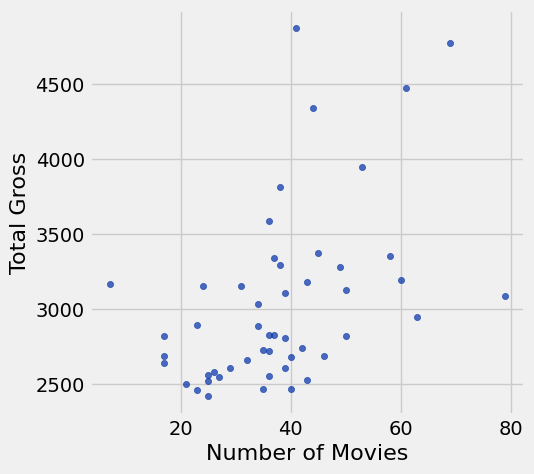

In [5]:

actors.scatter("Number of Movies", "Total Gross")

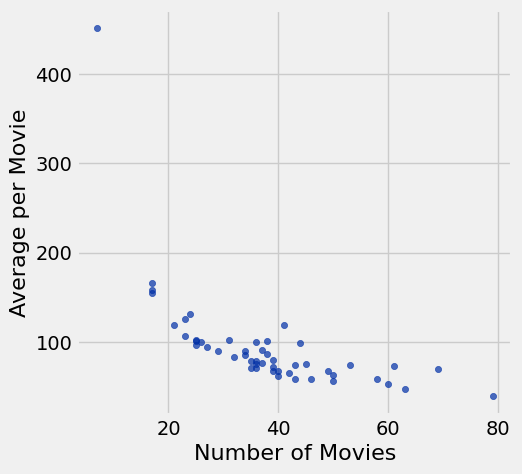

In [6]:
actors.scatter('Number of Movies', 'Average per Movie')

In [7]:
actors.where("Average per Movie", are.above(400))

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Anthony Daniels,3162.9,7,451.8,Star Wars: The Force Awakens,936.7


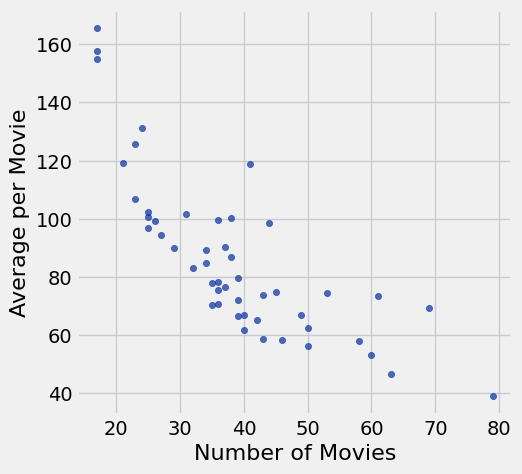

In [8]:
no_outlier = actors.where("Number of Movies", are.above(10))
no_outlier.scatter("Number of Movies", "Average per Movie")

In [9]:
# zoom in a little bit on those with more movies

actors.where("Number of Movies", are.above(60))

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Robert DeNiro,3081.3,79,39,Meet the Fockers,279.3
Liam Neeson,2942.7,63,46.7,The Phantom Menace,474.5


In [10]:
movies_by_year = Table.read_table(path_data + "movies_by_year.csv")

In [11]:
movies_by_year

Year,Total Gross,Number of Movies,#1 Movie
2015,11128.5,702,Star Wars: The Force Awakens
2014,10360.8,702,American Sniper
2013,10923.6,688,Catching Fire
2012,10837.4,667,The Avengers
2011,10174.3,602,Harry Potter / Deathly Hallows (P2)
2010,10565.6,536,Toy Story 3
2009,10595.5,521,Avatar
2008,9630.7,608,The Dark Knight
2007,9663.8,631,Spider-Man 3
2006,9209.5,608,Dead Man's Chest


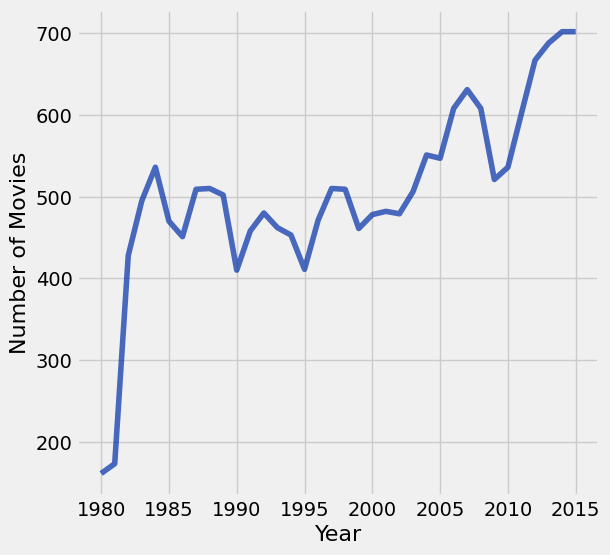

In [12]:
movies_by_year.plot("Year", "Number of Movies")

In [13]:
century_21 = movies_by_year.where("Year", are.above(1999))

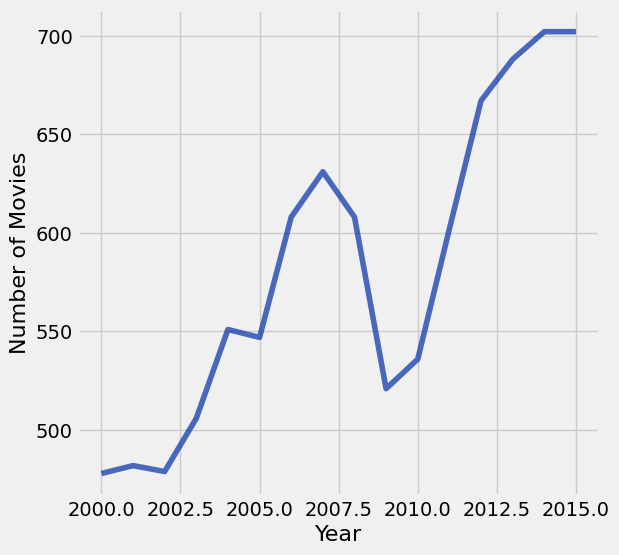

In [14]:
century_21.plot("Year", "Number of Movies")

In [15]:
century_21

Year,Total Gross,Number of Movies,#1 Movie
2015,11128.5,702,Star Wars: The Force Awakens
2014,10360.8,702,American Sniper
2013,10923.6,688,Catching Fire
2012,10837.4,667,The Avengers
2011,10174.3,602,Harry Potter / Deathly Hallows (P2)
2010,10565.6,536,Toy Story 3
2009,10595.5,521,Avatar
2008,9630.7,608,The Dark Knight
2007,9663.8,631,Spider-Man 3
2006,9209.5,608,Dead Man's Chest


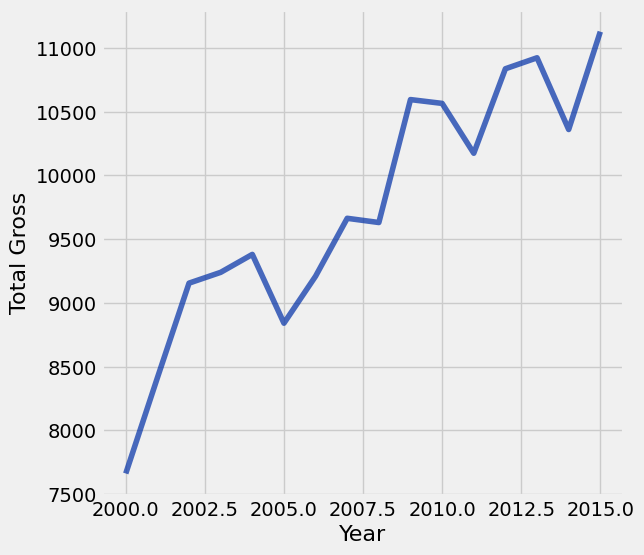

In [16]:
century_21.plot("Year", "Total Gross")

Though the number of movies dipped between 2008 and 2009, the total box office didn't do badly during the same period.

In [17]:
century_21.where("Year", 2009)

Year,Total Gross,Number of Movies,#1 Movie
2009,10595.5,521,Avatar


## Plotting categorical data

In [18]:
top = Table.read_table(path_data + "top_movies_2017.csv")
top

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


In [19]:
# What are the top studios
movies_and_studios = top.select("Title", "Studio")

## using the `group` to answer the question

In [20]:
studio_distro = movies_and_studios.group("Studio")
studio_distro

Studio,count
AVCO,1
Buena Vista,35
Columbia,9
Disney,11
Dreamworks,3
Fox,24
IFC,1
Lionsgate,3
MGM,7
Metro,1


In [22]:
sum(studio_distro.column("count"))

200

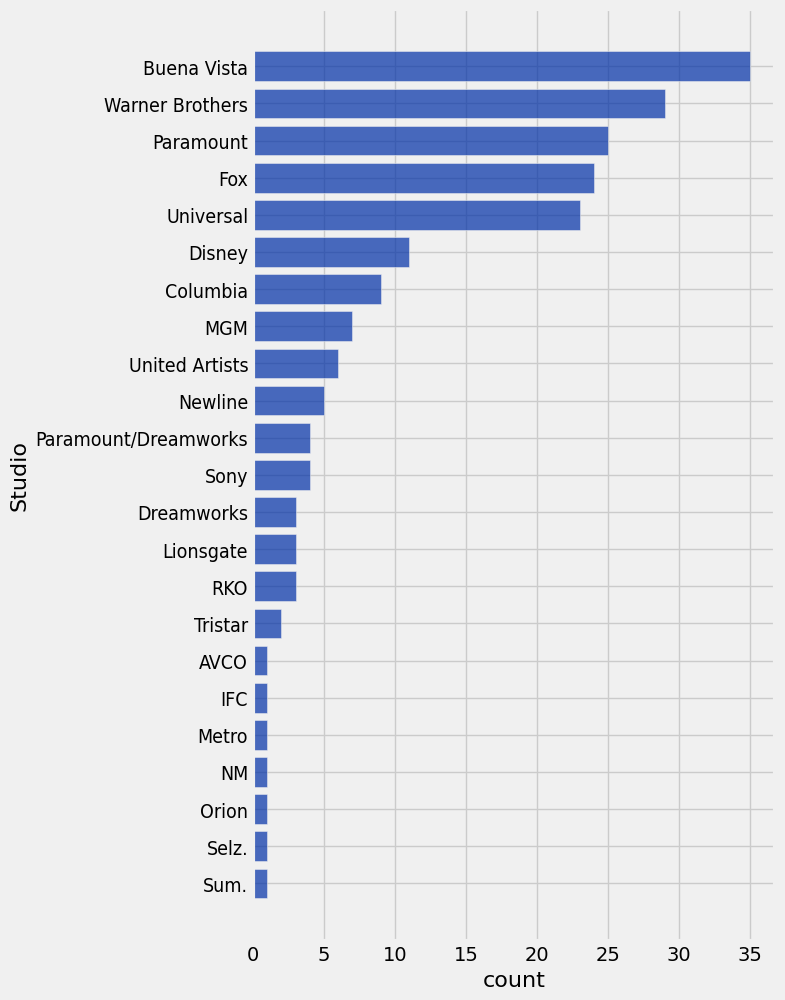

In [23]:
studio_distro.sort("count", descending=True).barh("Studio")

Buena vista: Walt Disney Motion Pictures : : Star Wars

Warner Brothers: Harry Potter

In [24]:
# How many movies per year?
movies_years = top.select("Title", "Year")
movies_years#.group()

Title,Year
Gone with the Wind,1939
Star Wars,1977
The Sound of Music,1965
E.T.: The Extra-Terrestrial,1982
Titanic,1997
The Ten Commandments,1956
Jaws,1975
Doctor Zhivago,1965
The Exorcist,1973
Snow White and the Seven Dwarves,1937


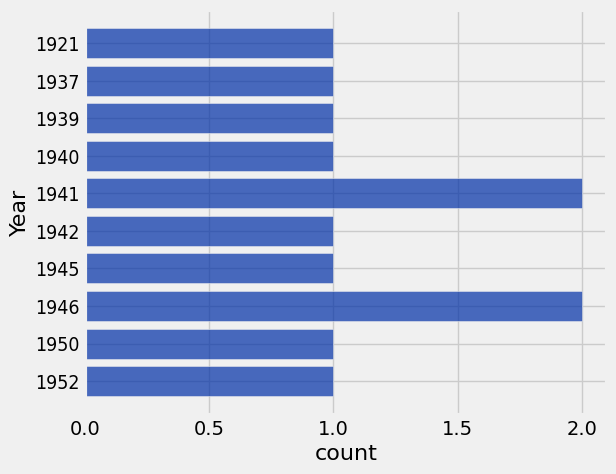

In [25]:
# The first 10 years in the distribution
movies_years.group("Year").take(np.arange(10)).barh("Year")

The `barh` doesn't show the years between 1921 and 1937, indicating that this may not be the best chart to use.

In [27]:
# to fix the Gross and Gross(Adjusted) columns 
top.set_format([2, 3], NumberFormatter)

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,"198,676,459","1,796,176,700",1939
Star Wars,Fox,"460,998,007","1,583,483,200",1977
The Sound of Music,Fox,"158,671,368","1,266,072,700",1965
E.T.: The Extra-Terrestrial,Universal,"435,110,554","1,261,085,000",1982
Titanic,Paramount,"658,672,302","1,204,368,000",1997
The Ten Commandments,Paramount,"65,500,000","1,164,590,000",1956
Jaws,Universal,"260,000,000","1,138,620,700",1975
Doctor Zhivago,MGM,"111,721,910","1,103,564,200",1965
The Exorcist,Warner Brothers,"232,906,145","983,226,600",1973
Snow White and the Seven Dwarves,Disney,"184,925,486","969,010,000",1937


In [29]:
# We take the title and add a column with the Gross Adjusted 
# rounded to 2 decimal places.
millions = top.select(0).with_columns("Adjusted Gross",
                           np.round(top.column(3)/1e6, 2))
millions

Title,Adjusted Gross
Gone with the Wind,1796.18
Star Wars,1583.48
The Sound of Music,1266.07
E.T.: The Extra-Terrestrial,1261.08
Titanic,1204.37
The Ten Commandments,1164.59
Jaws,1138.62
Doctor Zhivago,1103.56
The Exorcist,983.23
Snow White and the Seven Dwarves,969.01


## Binning the Data

Look at the values of the quantitative variable `Adjusted Gross`. There is likely to be only one movie at each individual value, since the values are being measured rather finely. It is more interesting to group the values into intervals, known as bins, and see how many movies are in each bin. This process is called `binning`.

The counts of individuals (that is, rows) in the bins can be computed using the `bin` method, analogous to the `group` method used in the case of categorical data.

The `bin` method takes as its argument a column label or index, and an optional argument in which you can specify the bins that you want.

The result is a two-column table that contains the number of rows in each bin. The first column lists the left endpoints of the bins (but see the note about the last bin, below).

Let’s try out the method and examine the details of the output. To choose some bins, we will start by looking at the smallest and largest values of Adjusted Gross.

In [30]:
adj_gross = millions.column('Adjusted Gross')
min(adj_gross), max(adj_gross)

(338.41000000000003, 1796.1800000000001)

In [31]:
bin_counts = millions.bin('Adjusted Gross', bins=np.arange(300,2001,100))
bin_counts.show()

bin,Adjusted Gross count
300,68
400,60
500,32
600,15
700,7
800,7
900,3
1000,0
1100,3
1200,3


Let's examine Column 0, the `bin` column. This column specifies the left end of each bin, except in the last row as explained below.
    
Since the bins split the number line into intervals, they are contiguous. So we must be careful about values at the endpoints. By the usual Python convention, each bin except the last includes its left endpoint but not its right endpoint.
    
To make this point, we will use the notation [*a, b*) to refer to the bin that contains all the values that are greater than or equal to *a* and strictly less than *b*.

To understand the first row of the table, you have to look at the second row as well. These two rows tell us that there were 68 movies in the bin [300, 400). That is, 68 movies had adjusted gross receipts of at least 300 million dollars but less than 400 million dollars.

In general, each element in the `Adjusted Gross count` column counts all the `Adjusted Gross` values that are greater than or equal to the value in `bin`, but less than the next value in `bin`.

**The last bin:** Notice the `bin` value 2000 in the last row. That's not the left endpoint of any bin. Instead, it's the right endpoint of the last bin. This bin is different from all the others in that it has the form [a, b]. It includes the data at *both* endpoints. In our example it doesn't matter because no movie made 2 billion dollars (that is, 2000 million). 

But this aspect of binning is important to keep in mind in case you want the bins to end exactly at the maximum value of the data. All the counts for this last bin appear in the second-to-last row, and the count for the last row is always zero.

There are other ways to use the `bin` method. If you don't specify any bins, the default is to produce 10 equally wide bins between the minimum and maximum values of the data. This is often useful for getting a quick sense of the distribution, but the endpoints of the bins tend to be alarming.


In [32]:
millions.bin("Adjusted Gross").show()

bin,Adjusted Gross count
338.41,115
484.187,50
629.964,14
775.741,10
921.518,3
1067.3,4
1213.07,2
1358.85,0
1504.63,1
1650.4,1


In [33]:
millions.bin("Adjusted Gross", bins=4)

bin,Adjusted Gross count
338.41,177
702.852,15
1067.3,6
1431.74,2
1796.18,0


Since it's quantitative data, the bins don't have to be equally wide.

## Histogram

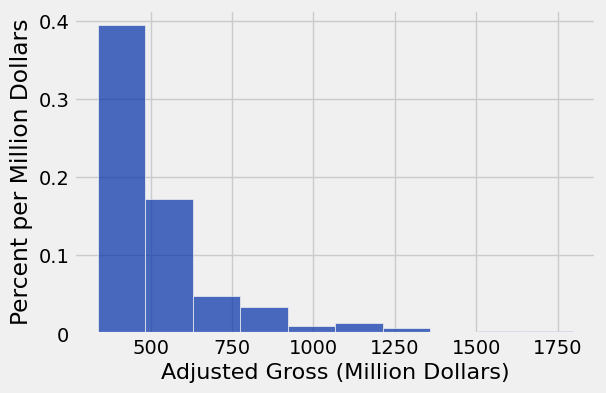

In [34]:
millions.hist("Adjusted Gross", unit="Million Dollars")

This figure has two numerical axes. We will take a quick look at the horizontal axis first, and then examine the vertical axis carefully. For now, just note that the vertical axis *does not* represent percents.

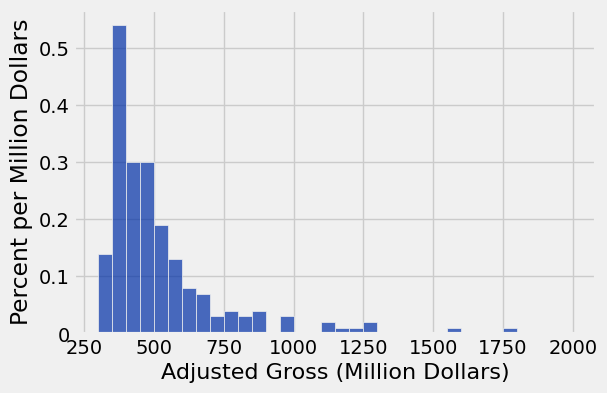

In [36]:
# Let's modify the histogram with the bins argument
millions.hist("Adjusted Gross", bins=np.arange(300, 2001, 50), unit="Million Dollars")

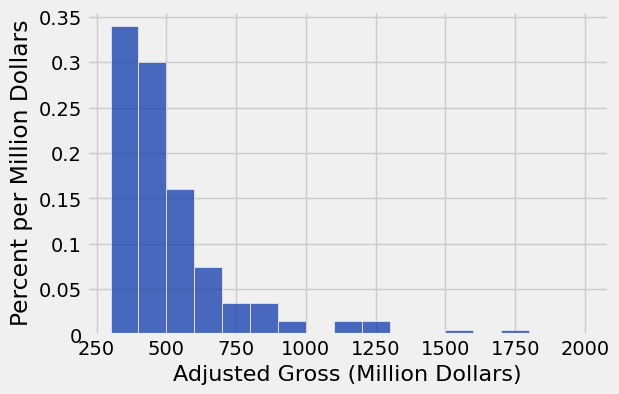

In [37]:
millions.hist("Adjusted Gross", bins=np.arange(300, 2001, 100), unit="Million Dollars")

Histograms follow the area principle and have two defining properties:

    The bins are drawn to scale and are contiguous (though some might be empty), because the values on the horizontal axis are numerical and therefore have fixed positions on the number line.

    The area of each bar is proportional to the number of entries in the bin.

Property 2 is the key to drawing a histogram, and is usually achieved as follows:

 `area of bar = percent of entries in bin`

Since areas represent percents, heights represent something other than percents. The numerical calculation of the heights just uses the fact that the bar is a rectangle:

 `area of bar = height of bar * width of bin`

and so

`height of bar = area of bar / width of bin = percent of entries in bin / width of bin`

The units of height are “percent per unit on the horizontal axis.” The height is the percent in the bin relative to the width of the bin. So it is called density or crowdedness.

When drawn using this method, the histogram is said to be drawn on the density scale. On this scale:

- The area of each bar is equal to the percent of data values that are in the corresponding bin.

- The total area of all the bars in the histogram is 100%. In terms of proportions, we can say that the areas of all the bars in a histogram “sum to 1”.


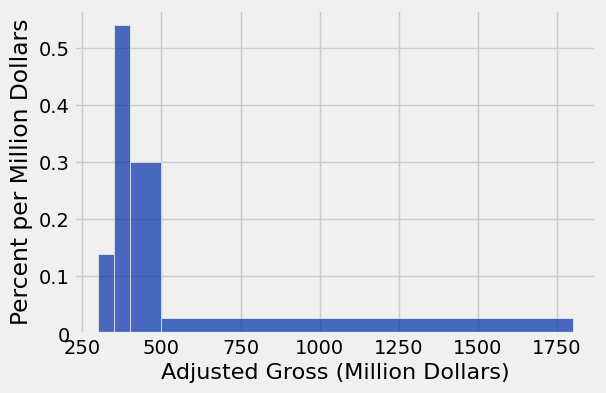

In [40]:
uneven = make_array(300, 350, 400, 500, 1800)
millions.hist('Adjusted Gross', bins=uneven, unit="Million Dollars")

In [41]:
millions.bin('Adjusted Gross', bins=uneven)

bin,Adjusted Gross count
300,14
350,54
400,60
500,72
1800,0


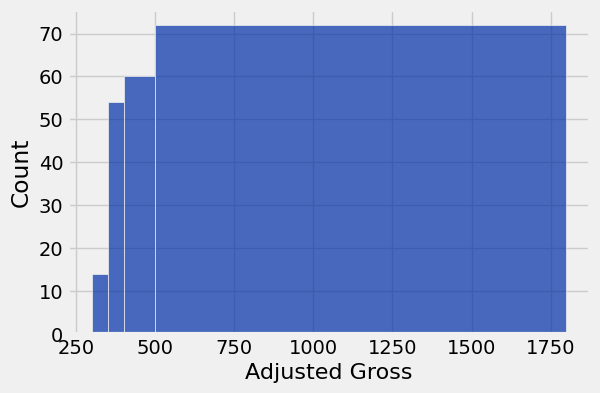

In [42]:
millions.hist('Adjusted Gross', bins=uneven, normed=False)

These two plots show what happens when the histogram is not on the density scale as explained earlier.